# BuildSafe-AI · Notebook 06 — Model Development
**IT3051 Fundamentals of Data Mining · Mini Project 2026 · Assignment Stage 6**

**Problem.** When a Department of Buildings inspector issues a violation, predict its **severity class** from the written description and context:
`CLASS - 1` = immediately hazardous · `CLASS - 2` = major · `CLASS - 3` = lesser. The model is a *triage aid*: the most important job is to **not miss Class 1**, without flooding inspectors with false alarms.

**What this notebook does.** It trains and compares **five algorithms** under one identical protocol, so differences between them are caused by the algorithm and not by the way it was tested.
Notebook 07 then tunes them, selects the final model and exports it for the backend.

| Assignment requirement (Stage 6) | Where it is covered |
|---|---|
| Implement at least **four** suitable algorithms | §4 — Logistic Regression, Linear SVM, Random Forest, LightGBM, XGBoost (+ a "majority class" reference line) |
| Select algorithms appropriate to the problem / dataset | §4 — rationale table (sparse TF-IDF text + a few categorical/numeric features, 3 imbalanced classes) |
| Use an appropriate validation strategy | §3 — time-ordered cross-validation, preprocessing **re-fitted inside every fold**, locked test set |
| Evaluate with suitable performance metrics | §2 — Macro-F1 (primary), Class-1 recall/precision, Class-3 recall/F1, accuracy, AUC |
| Compare performance systematically | §5–§6 — one table, same folds, same metrics, mean ± std |
| Record experiments, results, observations | §8 — `results/experiment_log.csv`, `stage6_*.csv/json`, saved figures |
| Understand *why* models do better or worse | §7 — evidence-based observations, feature insight, error analysis |

**Run order:** Notebook 02 (creates `artifacts/`) → **06 (this)** → 07.
**Runtime:** roughly 10–25 min on a normal laptop. Set `QUICK_RUN = True` in the first code cell for a 2-minute smoke test (small sample, **not** real results).

**Layout:** each of the five models has **its own cells** — definition (§4.1–4.5), cross-validation (§5.1–5.5) and hold-out test (§6b.1–6b.5) — so you can run, change or re-run one model without touching the others. Comparison tables and figures then collect all five.

### Key design decisions (decided before looking at any result)

| Decision | Choice | Why |
|---|---|---|
| Primary metric | **Macro-F1** | The three classes count equally; accuracy hides the rare Class 3 (≈ 4 %) |
| Safety metric | **Class-1 recall** (+ Class-1 precision) | A missed hazardous violation is the costly error; precision shows the false-alarm price |
| Validation | **Expanding-window time-series CV** on the training period | The system predicts *future* violations and the history features look backwards; random K-fold would train on the future |
| Leakage control | Leaky columns removed in Notebook 02; **all learned preprocessing re-fitted inside each fold** | A vocabulary / chi² selection fitted on all rows would have seen the validation rows' labels |
| Imbalance | Class weights (no SMOTE) | Real examples are enough; synthetic TF-IDF vectors are not real documents |
| Test set | **Locked** — only used in §6, reported once, never used to choose anything | Gives an honest final estimate |

## 0. Setup

In [1]:
import os, re, sys, json, time, gc, platform, warnings
from pathlib import Path
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
from scipy import sparse
from scipy.stats import loguniform

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.model_selection import TimeSeriesSplit, ParameterSampler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (precision_recall_fscore_support, confusion_matrix, roc_auc_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

try:
    import lightgbm as lgb
    import xgboost as xgb
except ImportError as e:
    raise ImportError("Install the boosting libraries first:   pip install lightgbm xgboost") from e

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", rc={"axes.titleweight": "bold"})
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)

# ---------------------------------------------------------------- run switches
RANDOM_STATE = 42          # same seed as Notebook 02, so every number is reproducible
QUICK_RUN = False          # True = tiny smoke test (small sample, few trials) -> checks the notebook runs end-to-end.
                           # Keep False to produce the real results for the report.
QUICK_RUN = QUICK_RUN or os.environ.get("BUILDSAFE_QUICK") == "1"
N_SPLITS = 3               # time-series CV folds (expanding window)

# ---------------------------------------------------------------- project paths (works from notebooks/ or notebooks/Models/)
def find_project_root():
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "artifacts" / "preprocessing_config.json").exists():
            return p
    raise FileNotFoundError("Could not find artifacts/preprocessing_config.json above the current folder. "
                            "Open this notebook from inside the BuildSafe-AI project (Notebook 02 must have been run).")

ROOT = find_project_root()
ART, MODELS, RESULTS = ROOT / "artifacts", ROOT / "models", ROOT / "results"
if QUICK_RUN:                       # a smoke test must never overwrite real results or the real exported model
    MODELS, RESULTS = MODELS / "quick_run", RESULTS / "quick_run"
FIG = RESULTS / "figures"
for d in (MODELS, RESULTS, FIG):
    d.mkdir(parents=True, exist_ok=True)

print("Project root :", ROOT)
print("QUICK_RUN    :", QUICK_RUN, "(smoke test - numbers are NOT final results)" if QUICK_RUN else "(full run)")
print("Versions     : python", platform.python_version(), "| numpy", np.__version__, "| pandas", pd.__version__,
      "| lightgbm", lgb.__version__, "| xgboost", xgb.__version__)
import sklearn; print("               scikit-learn", sklearn.__version__)

Project root : D:\FDM Pro\BuildSafe-AI
QUICK_RUN    : False (full run)
Versions     : python 3.13.7 | numpy 2.5.2 | pandas 3.0.5 | lightgbm 4.7.0 | xgboost 3.4.1
               scikit-learn 1.9.1


## 1. Load the data and re-check leakage safety
Notebook 02 produced the model-ready tables and matrices. Before modelling we **verify** (not assume) that they are consistent and leakage-free.
Note: the saved one-hot encoder was fitted on *string* categories, so categorical columns are cast to `str` when loading — the backend must do the same.

In [2]:
cfg = json.load(open(ART / "preprocessing_config.json", encoding="utf-8"))
FEATURES, TEXT_COL = cfg["features"], cfg["text_col"]
CAT_COLS, BIN_COLS, NUM_COLS = cfg["cat_cols"], cfg["bin_cols"], cfg["num_cols"]
TARGET = "SEVERITY"
CLASS_NAMES = ["CLASS - 1", "CLASS - 2", "CLASS - 3"]
CLASS_MEANING = {"CLASS - 1": "Immediately hazardous", "CLASS - 2": "Major", "CLASS - 3": "Lesser"}
LABEL2ID = {c: i for i, c in enumerate(CLASS_NAMES)}
SHORT = ["Class 1", "Class 2", "Class 3"]

def load_table(name):
    df = pd.read_csv(ART / name, parse_dates=["ISSUE_DATE"])
    df[TEXT_COL] = df[TEXT_COL].fillna("").astype(str)      # 6-18 rows have no description -> empty text
    df[CAT_COLS] = df[CAT_COLS].astype(str)                 # the saved encoder was fitted on STRING categories
    return df

train_df, test_df = load_table("train_engineered.csv"), load_table("test_engineered.csv")
y_train = train_df[TARGET].map(LABEL2ID).to_numpy()
y_test = test_df[TARGET].map(LABEL2ID).to_numpy()

# stored matrices from Notebook 02 (full training set; used for the final fits)
STORED = {
    "linear": (sparse.load_npz(ART / "X_train_linear.npz").tocsr().astype(np.float32),
               sparse.load_npz(ART / "X_test_linear.npz").tocsr().astype(np.float32)),
    "tree":   (sparse.load_npz(ART / "X_train_tree.npz").tocsr().astype(np.float32),
               sparse.load_npz(ART / "X_test_tree.npz").tocsr().astype(np.float32)),
}
names_linear = pd.read_csv(ART / "feature_names_linear.csv")["feature"].astype(str).to_numpy()
names_tree = pd.read_csv(ART / "feature_names_tree.csv")["feature"].astype(str).to_numpy()

# ---- consistency checks between the CSV tables and the stored matrices
assert train_df["ISSUE_DATE"].is_monotonic_increasing, "train_engineered.csv must be sorted by date"
assert (pd.read_csv(ART / "y_train.csv").squeeze().map(LABEL2ID).to_numpy() == y_train).all(), "y_train.csv does not match train_engineered.csv"
assert (pd.read_csv(ART / "y_test.csv").squeeze().map(LABEL2ID).to_numpy() == y_test).all(), "y_test.csv does not match test_engineered.csv"
for v in ("linear", "tree"):
    assert STORED[v][0].shape[0] == len(train_df) and STORED[v][1].shape[0] == len(test_df)
assert STORED["linear"][0].shape[1] == len(names_linear) and STORED["tree"][0].shape[1] == len(names_tree)

if QUICK_RUN:   # smoke test: keep the NEWEST 12,000 training rows and the OLDEST 4,000 test rows (time order preserved)
    NQ_TR, NQ_TE = 12000, 4000
    train_df, test_df = train_df.iloc[-NQ_TR:].reset_index(drop=True), test_df.iloc[:NQ_TE].reset_index(drop=True)
    y_train, y_test = y_train[-NQ_TR:], y_test[:NQ_TE]
    STORED = {v: (a[-NQ_TR:], b[:NQ_TE]) for v, (a, b) in STORED.items()}

print(f"train {train_df.shape}  {train_df.ISSUE_DATE.min().date()} -> {train_df.ISSUE_DATE.max().date()}")
print(f"test  {test_df.shape}  {test_df.ISSUE_DATE.min().date()} -> {test_df.ISSUE_DATE.max().date()}")
print("stored matrices  linear:", STORED["linear"][0].shape, "| tree:", STORED["tree"][0].shape)

train (81780, 17)  2025-01-01 -> 2026-05-12
test  (20554, 17)  2026-05-13 -> 2026-09-10
stored matrices  linear: (81780, 40072) | tree: (81780, 5000)


In [3]:
# ---- Leakage audit (assignment Stage 3/4: "identify potential data leakage and check how it will be prevented")
dropped = cfg["dropped_columns"]
leak_cols = [c for c, why in dropped.items() if "LEAKAGE" in why or "post-event" in why]
checks = {
    "No dropped / leaky column is a model input":                    not (set(FEATURES) & set(dropped)),
    "Target (SEVERITY) is not a model input":                        TARGET not in FEATURES,
    f"{len(leak_cols)} leakage / post-event columns were removed in Notebook 02": len(leak_cols) > 0,
    "No 'CLASS 1/2/3' wording left in the description text":         not train_df[TEXT_COL].str.contains(r"CLASS\s*[-#:.]?\s*[123](?![0-9])").any(),
    "No 'IMMEDIATELY HAZARDOUS' phrase left in the text":            not train_df[TEXT_COL].str.contains("IMMEDIATELY HAZARDOUS").any(),
    "Training period ends before the test period starts":            train_df["ISSUE_DATE"].max() < test_df["ISSUE_DATE"].min(),
    "Rows are in chronological order (needed for time-series CV)":   bool(train_df["ISSUE_DATE"].is_monotonic_increasing),
}
display(pd.Series(checks, name="passed").to_frame())
assert all(checks.values()), "A leakage check failed - fix Notebook 02 before modelling."

# ---- Class distribution and class weights
dist = pd.DataFrame({"train rows": pd.Series(y_train).map(dict(enumerate(CLASS_NAMES))).value_counts(),
                     "test rows": pd.Series(y_test).map(dict(enumerate(CLASS_NAMES))).value_counts()}).reindex(CLASS_NAMES)
dist["train %"] = (dist["train rows"] / dist["train rows"].sum() * 100).round(2)
dist["test %"] = (dist["test rows"] / dist["test rows"].sum() * 100).round(2)
dist["meaning"] = [CLASS_MEANING[c] for c in CLASS_NAMES]
display(dist)
cw = {c: round(w, 3) for c, w in zip(CLASS_NAMES, compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y_train))}
print("Balanced class weights computed from the training labels:", cw)
if not QUICK_RUN:
    print("Saved in artifacts/class_weights.json            :", json.load(open(ART / "class_weights.json")))

,passed
No dropped / leaky column is a model input,True
Target (SEVERITY) is not a model input,True
13 leakage / post-event columns were removed in Notebook 02,True
No 'CLASS 1/2/3' wording left in the description text,True
No 'IMMEDIATELY HAZARDOUS' phrase left in the text,True
Training period ends before the test period starts,True
Rows are in chronological order (needed for time-series CV),True


,train rows,test rows,train %,test %,meaning
CLASS - 1,32140,8455,39.30,41.14,Immediately hazardous
CLASS - 2,46270,11282,56.58,54.89,Major
CLASS - 3,3370,817,4.12,3.97,Lesser


Balanced class weights computed from the training labels: {'CLASS - 1': np.float64(0.848), 'CLASS - 2': np.float64(0.589), 'CLASS - 3': np.float64(8.089)}
Saved in artifacts/class_weights.json            : {'CLASS - 1': 0.848, 'CLASS - 2': 0.589, 'CLASS - 3': 8.089}


**Reading:** Class 3 is only ≈ 4 % of rows (≈ 14 : 1 against Class 2), so a model that never predicts Class 3 would still look "85 % accurate". That is why Macro-F1 is the primary metric and class weights are used.
The class mix of train and test is close, so the chronological split does not create an artificial imbalance shift.

## 2. Evaluation metrics
All models are scored with the **same** function on the **same** data.

| Metric | Meaning | Why it is here |
|---|---|---|
| **Macro-F1** (primary) | mean of the three per-class F1 scores | treats every class equally → penalises ignoring Class 3 |
| **Class-1 recall** | share of hazardous violations that are caught | the safety goal |
| **Class-1 precision** | share of "Class 1" alerts that really are Class 1 | the false-alarm cost (a model can fake high recall by predicting Class 1 for everything) |
| **Class-3 recall / F1** | how well the rare class is handled | imbalance check |
| **Class-1 → Class-3 rate** | hazardous violations labelled *lesser* | the most dangerous mistake (two levels off) |
| Accuracy, Macro AUC (one-vs-rest) | overall correctness / ranking quality | reported for completeness (AUC needs scores: probabilities, or margins for the SVM) |

In [4]:
def macro_ovr_auc(y, S):
    """Macro one-vs-rest ROC-AUC from any score matrix (probabilities OR SVM margins)."""
    aucs = []
    for c in range(3):
        yb = (y == c).astype(int)
        if 0 < yb.sum() < len(yb):
            aucs.append(roc_auc_score(yb, S[:, c]))
    return float(np.mean(aucs))

def evaluate(y, pred, S=None):
    """One dictionary of all metrics used in this project (class ids: 0 = Class 1, 1 = Class 2, 2 = Class 3)."""
    p, r, f, _ = precision_recall_fscore_support(y, pred, labels=[0, 1, 2], zero_division=0)
    cm = confusion_matrix(y, pred, labels=[0, 1, 2])
    out = dict(macro_f1=f.mean(), accuracy=float((pred == y).mean()), balanced_accuracy=r.mean(),
               c1_recall=r[0], c1_precision=p[0], c1_f1=f[0], c2_f1=f[1],
               c3_recall=r[2], c3_precision=p[2], c3_f1=f[2],
               c1_as_c3=cm[0, 2] / max(cm[0].sum(), 1))          # most dangerous error: hazardous -> lesser
    if S is not None:
        out["macro_auc_ovr"] = macro_ovr_auc(y, S)
    return {k: float(v) for k, v in out.items()}

METRIC_COLS = ["macro_f1", "accuracy", "c1_recall", "c1_precision", "c3_recall", "c3_f1", "macro_auc_ovr"]
METRIC_LABELS = {"macro_f1": "Macro-F1", "accuracy": "Accuracy", "c1_recall": "Class-1 recall", "c1_precision": "Class-1 precision",
                 "c3_recall": "Class-3 recall", "c3_f1": "Class-3 F1", "macro_auc_ovr": "Macro AUC (OvR)",
                 "balanced_accuracy": "Balanced acc.", "c1_as_c3": "Class-1 -> Class-3 rate", "c1_f1": "Class-1 F1", "c2_f1": "Class-2 F1"}

## 3. Validation strategy — time-ordered cross-validation
The deployed system always predicts **newer** violations than it was trained on, and the building-history features look *backwards in time*. A random K-fold would train on future rows and give an over-optimistic score.
So the training period (sorted by date) is cut into **expanding windows**:

```
Fold 1: train [####]            validate [#]
Fold 2: train [########]        validate [#]
Fold 3: train [############]    validate [#]
                                                  test (locked) [#####]
```
**Leakage-safe preprocessing.** In each fold the TF-IDF vocabulary/IDF weights, one-hot categories, MinMax ranges and the chi² feature ranking are **re-fitted on that fold's training rows only** and then applied to its validation rows.
(The pre-built matrices from Notebook 02 are fitted on the whole training period; using them inside CV would let the validation rows' labels influence the chi² selection.)
Class weights are also recomputed from each fold's training labels. The 3 folds also act as a mini learning curve (20 k → 41 k → 61 k training rows).

In [5]:
def make_features():
    """The SAME ColumnTransformer recipe as Notebook 02 (TF-IDF + one-hot + passthrough + log1p/MinMax).
    Built from code (not cloned from the .joblib) so it can be re-fitted inside every CV fold on any scikit-learn version."""
    log_minmax = Pipeline([("log", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
                           ("scale", MinMaxScaler(clip=True))])
    return ColumnTransformer([
        ("text", TfidfVectorizer(ngram_range=(1, 2), min_df=5, max_df=0.9, sublinear_tf=True, max_features=40000,
                                 lowercase=False, token_pattern=r"(?u)\b[A-Z]{2,}\b|\b\d+-\d+(?:\.\d+)*\b"), TEXT_COL),
        ("cat", OneHotEncoder(handle_unknown="infrequent_if_exist", min_frequency=50, sparse_output=True), CAT_COLS),
        ("bin", "passthrough", BIN_COLS),
        ("num", log_minmax, NUM_COLS)], sparse_threshold=1.0, verbose_feature_names_out=True)

def top_k_columns(scores, k):
    """Columns kept by SelectKBest(chi2, k) - same rule as scikit-learn (stable sort, NaN = worst), returned in column order."""
    s = np.nan_to_num(scores, nan=np.finfo(np.float64).min)
    return np.sort(np.argsort(s, kind="mergesort")[-k:])

def build_cv_folds(df, y, n_splits=N_SPLITS):
    """Expanding-window time-series folds. Inside EVERY fold the whole preprocessing (TF-IDF vocabulary + IDF, one-hot
    categories, MinMax ranges, chi2 scores) is fitted on that fold's TRAINING rows only and then applied to its validation rows."""
    folds = []
    for fi, (tr, va) in enumerate(TimeSeriesSplit(n_splits=n_splits).split(df)):
        t0 = time.time()
        feats = make_features()
        Xtr = feats.fit_transform(df.iloc[tr][FEATURES], y[tr]).tocsr().astype(np.float32)
        Xva = feats.transform(df.iloc[va][FEATURES]).tocsr().astype(np.float32)
        scores = chi2(Xtr, y[tr])[0]
        folds.append(dict(i=fi, tr_idx=tr, va_idx=va, y_tr=y[tr], y_va=y[va], Xtr=Xtr, Xva=Xva,
                          scores=scores, names=np.asarray(feats.get_feature_names_out()), cache={}))
        print(f"fold {fi + 1}/{n_splits}: train {len(tr):>6,} | validation {len(va):>6,} | {Xtr.shape[1]:,} features | {time.time() - t0:.0f}s")
    return folds

def fold_matrices(f, view, k=None, drop=None):
    """Matrices of one fold for a model 'view'. linear view = all features, tree view = top-k chi2 features (k default 5000).
    `drop` = list of name fragments to remove (used by the feature-group ablation)."""
    key = (view, k, tuple(drop or ()))
    if key in f["cache"]:
        return f["cache"][key]
    n_all = f["Xtr"].shape[1]
    cols = np.arange(n_all) if k is None or k >= n_all else top_k_columns(f["scores"], k)
    if drop:
        pat = "|".join(re.escape(d) for d in drop)
        cols = cols[~pd.Series(f["names"][cols]).str.contains(pat).to_numpy()]
    out = (f["Xtr"], f["Xva"]) if len(cols) == n_all else (f["Xtr"][:, cols], f["Xva"][:, cols])
    if len(f["cache"]) >= 6:                       # keep memory bounded
        f["cache"].pop(next(iter(f["cache"])))
    f["cache"][key] = out
    return out

Building leakage-safe CV folds (preprocessing re-fitted inside each fold) ...
fold 1/3: train 20,445 | validation 20,445 | 16,280 features | 2s
fold 2/3: train 40,890 | validation 20,445 | 27,855 features | 3s
fold 3/3: train 61,335 | validation 20,445 | 38,033 features | 4s


,train rows,validation rows,train period,validation period,val Class 1 %,val Class 2 %,val Class 3 %
fold,,,,,,,
1,20445,20445,2025-01-01 -> 2025-05-02,2025-05-02 -> 2025-09-09,41.0,55.1,3.9
2,40890,20445,2025-01-01 -> 2025-09-09,2025-09-09 -> 2026-01-23,43.4,52.1,4.5
3,61335,20445,2025-01-01 -> 2026-01-23,2026-01-23 -> 2026-05-12,37.7,59.1,3.2


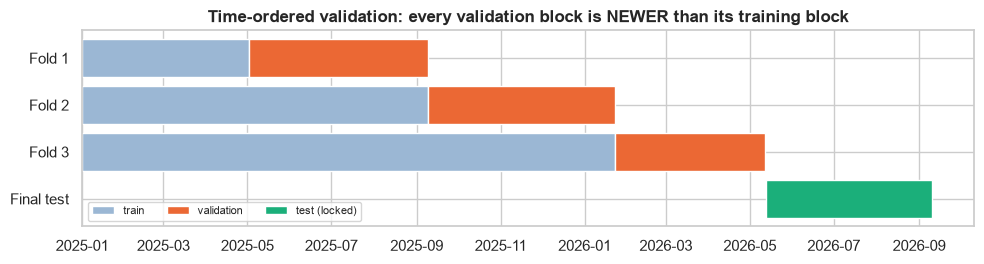

In [6]:
print("Building leakage-safe CV folds (preprocessing re-fitted inside each fold) ...")
FOLDS = build_cv_folds(train_df, y_train)

rows = []
for f in FOLDS:
    d = train_df["ISSUE_DATE"]
    va_dist = np.bincount(f["y_va"], minlength=3) / len(f["y_va"]) * 100
    rows.append({"fold": f["i"] + 1, "train rows": len(f["tr_idx"]), "validation rows": len(f["va_idx"]),
                 "train period": f"{d.iloc[f['tr_idx'][0]].date()} -> {d.iloc[f['tr_idx'][-1]].date()}",
                 "validation period": f"{d.iloc[f['va_idx'][0]].date()} -> {d.iloc[f['va_idx'][-1]].date()}",
                 "val Class 1 %": round(va_dist[0], 1), "val Class 2 %": round(va_dist[1], 1), "val Class 3 %": round(va_dist[2], 1)})
display(pd.DataFrame(rows).set_index("fold"))

fig, ax = plt.subplots(figsize=(10, 2.8))
d = train_df["ISSUE_DATE"]
for f in FOLDS:
    a0, a1, b0, b1 = d.iloc[f["tr_idx"][0]], d.iloc[f["tr_idx"][-1]], d.iloc[f["va_idx"][0]], d.iloc[f["va_idx"][-1]]
    ax.barh(f["i"], (a1 - a0).days, left=mdates.date2num(a0), color="#9bb7d4", label="train" if f["i"] == 0 else None)
    ax.barh(f["i"], (b1 - b0).days, left=mdates.date2num(b0), color="#eb6834", label="validation" if f["i"] == 0 else None)
t0_, t1_ = test_df["ISSUE_DATE"].min(), test_df["ISSUE_DATE"].max()
ax.barh(len(FOLDS), (t1_ - t0_).days, left=mdates.date2num(t0_), color="#1baf7a", label="test (locked)")
ax.set_yticks(range(len(FOLDS) + 1)); ax.set_yticklabels([f"Fold {i + 1}" for i in range(len(FOLDS))] + ["Final test"])
ax.xaxis_date(); ax.invert_yaxis(); ax.legend(loc="lower left", ncol=3, fontsize=8)
ax.set_title("Time-ordered validation: every validation block is NEWER than its training block")
plt.tight_layout(); plt.savefig(FIG / "06_fig1_validation_timeline.png", dpi=150, bbox_inches="tight"); plt.show()

## 4. The algorithms
Five algorithms from three families were chosen because the data is **very high-dimensional and sparse** (40 000 TF-IDF word/bigram columns + ~70 structured columns) with three imbalanced classes:

| Model | Family | Why it is suitable here | Input matrix |
|---|---|---|---|
| **Logistic Regression** | linear, probabilistic | classic strong baseline for TF-IDF text; coefficients are directly interpretable ("which words push towards Class 1") | all ≈ 40 k features (scaled) |
| **Linear SVM** (`LinearSVC`) | linear, max-margin | usually the best linear learner on sparse text; fast; no probabilities (margins only) | all ≈ 40 k features |
| **Random Forest** | bagged trees | non-linear; combines text with context (violation type, building history); robust, little tuning needed | top-5 000 chi² features |
| **LightGBM** | gradient-boosted trees | handles sparse input efficiently; learns interactions sequentially; state of the art on tabular data | top-5 000 chi² features |
| **XGBoost** | gradient-boosted trees | second boosting implementation — shows whether the *library* matters or only the *method* | top-5 000 chi² features |

Linear models receive **all** features (Notebook 02 showed chi² selection does not help them); tree models receive the top 5 000 (faster, less noise).
A "majority class" predictor is added only as a **reference line** (any real model must beat it clearly).
Baseline settings below are sensible defaults fixed in advance; tuning happens in Notebook 07.
Each model is defined in **its own cell** (§4.1–4.5) and plugged into one shared evaluation engine (§4.6).

In [7]:
MODEL_NAMES = ["Logistic Regression", "Linear SVM", "Random Forest", "LightGBM", "XGBoost"]

# Every model fills in its OWN entry of these four dictionaries in its own cell below (4.1 ... 4.5):
VIEW     = {}   # which input matrix the model gets: "linear" = scaled sparse matrix, ALL features | "tree" = top-k chi2 features
BASELINE = {}   # baseline settings = sensible defaults, decided BEFORE looking at any result.
                # 'k' = number of chi2-selected features (tree view only), 'alpha' = strength of class balancing (1.0 = fully 'balanced', 0 = none)
BUILDERS = {}   # function that creates the unfitted model (+ extra fit kwargs)
SCORERS  = {}   # function that returns class scores (probabilities; margins for the SVM)

def class_weight_dict(y, alpha=1.0):
    """'balanced' weights (n / (3 * count)) raised to the power alpha, computed from the TRAINING labels passed in."""
    w = compute_class_weight("balanced", classes=np.array([0, 1, 2]), y=y)
    return {i: float(w[i] ** alpha) for i in range(3)}

def clean_params(p):
    """numpy scalars -> plain python (for JSON / printing)."""
    return {k: (v.item() if isinstance(v, np.generic) else v) for k, v in p.items()}

### 4.1 Logistic Regression
Linear, probabilistic. Gets **all** ≈ 40 k scaled features. Coefficients are directly interpretable (§7). `alpha` = class-weight strength, `C` = inverse regularisation strength.

In [8]:
# =============================== MODEL 1 / 5 : LOGISTIC REGRESSION ===============================
VIEW["Logistic Regression"] = "linear"
BASELINE["Logistic Regression"] = dict(C=1.0, max_iter=300, alpha=1.0)

def build_logistic_regression(p, cw, y_fit):
    """Returns (unfitted model, extra fit kwargs). `cw` = class-weight dict computed from the training rows only."""
    return LogisticRegression(C=p["C"], class_weight=cw, solver="lbfgs", max_iter=p["max_iter"]), {}

def score_logistic_regression(model, X, n_iter=None):
    return model.predict_proba(X)

BUILDERS["Logistic Regression"], SCORERS["Logistic Regression"] = build_logistic_regression, score_logistic_regression
print("Logistic Regression  | input:", VIEW["Logistic Regression"], "| baseline:", BASELINE["Logistic Regression"])

Logistic Regression  | input: linear | baseline: {'C': 1.0, 'max_iter': 300, 'alpha': 1.0}


### 4.2 Linear SVM (`LinearSVC`)
Linear, max-margin; usually the strongest linear learner on sparse text and very fast. It has **no probabilities** (margins only), so it is reported but cannot be the deployed model in Notebook 07.

In [9]:
# =============================== MODEL 2 / 5 : LINEAR SVM ===============================
VIEW["Linear SVM"] = "linear"
BASELINE["Linear SVM"] = dict(C=1.0, alpha=1.0)

def build_linear_svm(p, cw, y_fit):
    return LinearSVC(C=p["C"], class_weight=cw, max_iter=5000, random_state=RANDOM_STATE), {}

def score_linear_svm(model, X, n_iter=None):
    return model.decision_function(X)            # margins, not probabilities

BUILDERS["Linear SVM"], SCORERS["Linear SVM"] = build_linear_svm, score_linear_svm
print("Linear SVM           | input:", VIEW["Linear SVM"], "| baseline:", BASELINE["Linear SVM"])

Linear SVM           | input: linear | baseline: {'C': 1.0, 'alpha': 1.0}


### 4.3 Random Forest
Bagged trees; non-linear, combines text with context (violation type, building history). Gets the **top-5 000 chi²** features.

In [10]:
# =============================== MODEL 3 / 5 : RANDOM FOREST ===============================
VIEW["Random Forest"] = "tree"
BASELINE["Random Forest"] = dict(n_estimators=40 if QUICK_RUN else 200,      # QUICK_RUN: fewer trees so the smoke test is fast
                                 max_depth=None, min_samples_leaf=1, max_features="sqrt", k=5000, alpha=1.0)

def build_random_forest(p, cw, y_fit):
    return RandomForestClassifier(n_estimators=p["n_estimators"], max_depth=p["max_depth"], min_samples_leaf=p["min_samples_leaf"],
                                  max_features=p["max_features"], class_weight=cw, n_jobs=-1, random_state=RANDOM_STATE), {}

def score_random_forest(model, X, n_iter=None):
    return model.predict_proba(X)

BUILDERS["Random Forest"], SCORERS["Random Forest"] = build_random_forest, score_random_forest
print("Random Forest        | input:", VIEW["Random Forest"], "| baseline:", BASELINE["Random Forest"])

Random Forest        | input: tree | baseline: {'n_estimators': 200, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'k': 5000, 'alpha': 1.0}


### 4.4 LightGBM
Gradient-boosted trees (leaf-wise growth); efficient on sparse input and learns interactions sequentially. Gets the **top-5 000 chi²** features. Boosting libraries take **per-row sample weights** instead of a `class_weight` dict.

In [11]:
# =============================== MODEL 4 / 5 : LIGHTGBM ===============================
VIEW["LightGBM"] = "tree"
BASELINE["LightGBM"] = dict(n_estimators=60 if QUICK_RUN else 300,           # QUICK_RUN: fewer trees so the smoke test is fast
                            learning_rate=0.1, num_leaves=31, min_child_samples=20,
                            colsample_bytree=1.0, subsample=1.0, reg_lambda=0.0, k=5000, alpha=1.0)

def build_lightgbm(p, cw, y_fit):
    sw = np.asarray([cw[0], cw[1], cw[2]])[y_fit]                      # per-row sample weights from the class weights
    m = lgb.LGBMClassifier(objective="multiclass", n_estimators=p["n_estimators"], learning_rate=p["learning_rate"],
                           num_leaves=p["num_leaves"], min_child_samples=p["min_child_samples"], colsample_bytree=p["colsample_bytree"],
                           subsample=p["subsample"], subsample_freq=1, reg_lambda=p["reg_lambda"],
                           random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    return m, {"sample_weight": sw}

def score_lightgbm(model, X, n_iter=None):
    """n_iter = use only the first n_iter trees (staged evaluation used by the tuning in Notebook 07)."""
    return model.predict_proba(X, num_iteration=n_iter) if n_iter else model.predict_proba(X)

BUILDERS["LightGBM"], SCORERS["LightGBM"] = build_lightgbm, score_lightgbm
print("LightGBM             | input:", VIEW["LightGBM"], "| baseline:", BASELINE["LightGBM"])

LightGBM             | input: tree | baseline: {'n_estimators': 300, 'learning_rate': 0.1, 'num_leaves': 31, 'min_child_samples': 20, 'colsample_bytree': 1.0, 'subsample': 1.0, 'reg_lambda': 0.0, 'k': 5000, 'alpha': 1.0}


### 4.5 XGBoost
Second boosting implementation (level-wise growth) — shows whether the *library* matters or only the *method*. Gets the **top-5 000 chi²** features.

In [12]:
# =============================== MODEL 5 / 5 : XGBOOST ===============================
VIEW["XGBoost"] = "tree"
BASELINE["XGBoost"] = dict(n_estimators=40 if QUICK_RUN else 300,            # QUICK_RUN: fewer trees so the smoke test is fast
                           learning_rate=0.1, max_depth=6, min_child_weight=1,
                           subsample=0.8, colsample_bytree=0.5, reg_lambda=1.0, k=5000, alpha=1.0)

def build_xgboost(p, cw, y_fit):
    sw = np.asarray([cw[0], cw[1], cw[2]])[y_fit]                      # per-row sample weights from the class weights
    m = xgb.XGBClassifier(objective="multi:softprob", n_estimators=p["n_estimators"], learning_rate=p["learning_rate"],
                          max_depth=p["max_depth"], min_child_weight=p["min_child_weight"], subsample=p["subsample"],
                          colsample_bytree=p["colsample_bytree"], reg_lambda=p["reg_lambda"], tree_method="hist",
                          eval_metric="mlogloss", random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    return m, {"sample_weight": sw}

def score_xgboost(model, X, n_iter=None):
    """n_iter = use only the first n_iter trees (staged evaluation used by the tuning in Notebook 07)."""
    return model.predict_proba(X, iteration_range=(0, n_iter)) if n_iter else model.predict_proba(X)

BUILDERS["XGBoost"], SCORERS["XGBoost"] = build_xgboost, score_xgboost
print("XGBoost              | input:", VIEW["XGBoost"], "| baseline:", BASELINE["XGBoost"])

XGBoost              | input: tree | baseline: {'n_estimators': 300, 'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 1, 'subsample': 0.8, 'colsample_bytree': 0.5, 'reg_lambda': 1.0, 'k': 5000, 'alpha': 1.0}


### 4.6 Shared evaluation engine
The five models above are plugged into **one** cross-validation engine, so every model is trained, scored and logged by exactly the same code — differences between the models therefore come from the algorithm, not from the way it was tested.

In [13]:
missing = [n for n in MODEL_NAMES if n not in BUILDERS]
assert not missing, f"Run the model cells 4.1-4.5 first - not defined yet: {missing}"

def build_model(name, overrides, y_fit):
    """Returns (unfitted model, extra fit kwargs). Class weights are always computed from y_fit (training rows only)."""
    p = {**BASELINE[name], **(overrides or {})}
    cw = class_weight_dict(y_fit, p.get("alpha", 1.0))
    return BUILDERS[name](p, cw, y_fit)

def score_model(name, model, X, n_iter=None):
    """Class scores (probabilities; SVM margins). For boosting, n_iter = use only the first n_iter trees (staged evaluation)."""
    return SCORERS[name](model, X, n_iter)

def cv_evaluate(name, overrides=None, *, folds=None, checkpoints=None, keep_oof=False, k=None, drop=None, alpha=None):
    """Time-series CV of ONE configuration.
    checkpoints (boosting only): fit once with max(checkpoints) trees and score the validation fold after every checkpoint;
    the number of trees with the best mean macro-F1 is reported as best_iter (number of trees = a tuned hyper-parameter)."""
    folds = folds or FOLDS
    p = {**BASELINE[name], **clean_params(overrides or {})}
    if k is not None:
        p["k"] = k
    if alpha is not None:
        p["alpha"] = alpha
    view, kk = VIEW[name], p.get("k")
    staged = bool(checkpoints) and name in ("LightGBM", "XGBoost")
    ckpts = list(checkpoints) if staged else [None]
    if staged:
        p["n_estimators"] = max(ckpts)
    rows = {c: [] for c in ckpts}
    last_scores, fit_s = {}, []
    for f in folds:
        Xtr, Xva = fold_matrices(f, view, kk, drop)
        model, fkw = build_model(name, p, f["y_tr"])
        t0 = time.time()
        model.fit(Xtr, f["y_tr"], **fkw)
        fit_s.append(time.time() - t0)
        for c in ckpts:
            S = score_model(name, model, Xva, c)
            rows[c].append(evaluate(f["y_va"], S.argmax(1), S))
            if keep_oof and f["i"] == folds[-1]["i"]:
                last_scores[c] = S
        del model
    curve = {c: float(np.mean([r["macro_f1"] for r in rows[c]])) for c in ckpts}
    best = max(curve, key=curve.get)
    per_fold = rows[best]
    summary = {}
    for m in per_fold[0]:
        vals = [r[m] for r in per_fold]
        summary[f"{m}_mean"], summary[f"{m}_std"] = float(np.mean(vals)), float(np.std(vals))
    best_iter = best if staged else (p["n_estimators"] if name in ("LightGBM", "XGBoost") else None)
    return dict(name=name, params=p, best_iter=best_iter, summary=summary, per_fold=per_fold,
                curve={c: v for c, v in curve.items() if c is not None}, fit_s=float(np.mean(fit_s)),
                n_features=int(Xtr.shape[1]),
                oof=(folds[-1]["y_va"], last_scores[best]) if keep_oof else None)

def results_table(results):
    """Dict {model: cv_evaluate result} -> tidy DataFrame with mean +/- std."""
    rows = []
    for name, r in results.items():
        s = r["summary"]
        row = {"Model": name}
        for m in METRIC_COLS:
            if f"{m}_mean" in s:
                row[METRIC_LABELS[m]] = f"{s[m + '_mean']:.4f} +/- {s[m + '_std']:.4f}"
        row["Fit time / fold (s)"] = round(r["fit_s"], 1)
        rows.append(row)
    return pd.DataFrame(rows).set_index("Model")

# ---- experiment log (one row per run, merged into results/experiment_log.csv)
EXPERIMENTS = []
def log_experiment(notebook, stage, name, res, label=""):
    EXPERIMENTS.append(dict(notebook=notebook, stage=stage, model=name, label=label,
                            params=json.dumps(res["params"], default=str), best_iter=res["best_iter"], n_features=res["n_features"],
                            fit_seconds=round(res["fit_s"], 1),
                            **{k: round(v, 4) for k, v in res["summary"].items()},
                            timestamp=datetime.now().isoformat(timespec="seconds")))

def save_experiment_log(notebook):
    path = RESULTS / "experiment_log.csv"
    new = pd.DataFrame(EXPERIMENTS)
    if path.exists():
        old = pd.read_csv(path)
        old = old[old["notebook"] != notebook]            # re-running a notebook replaces its own rows
        new = pd.concat([old, new], ignore_index=True)
    new.to_csv(path, index=False)
    return path, len(new)

In [14]:
base_table = pd.DataFrame({n: {k: v for k, v in BASELINE[n].items()} for n in MODEL_NAMES}).T
base_table.insert(0, "input matrix", [VIEW[n] for n in MODEL_NAMES])
display(base_table.fillna("-"))

,input matrix,C,max_iter,alpha,n_estimators,max_depth,min_samples_leaf,max_features,k,learning_rate,num_leaves,min_child_samples,colsample_bytree,subsample,reg_lambda,min_child_weight
Logistic Regression,linear,1.0,300.0,1.0,-,-,-,-,-,-,-,-,-,-,-,-
Linear SVM,linear,1.0,-,1.0,-,-,-,-,-,-,-,-,-,-,-,-
Random Forest,tree,-,-,1.0,200,-,1,sqrt,5000,-,-,-,-,-,-,-
LightGBM,tree,-,-,1.0,300.0,-,-,-,5000.0,0.1,31.0,20.0,1.0,1.0,0.0,-
XGBoost,tree,-,-,1.0,300.0,6.0,-,-,5000.0,0.1,-,-,0.5,0.8,1.0,1.0


## 5. Baseline comparison with time-series cross-validation
Every model is fitted on each fold's training window and scored on the following (newer) validation window.
Boosting models use a fixed number of trees here (no early stopping on the validation fold, which would be a mild form of leakage); the number of trees is tuned properly in Notebook 07.

In [15]:
NB = "06_model_development"
BASELINE_RESULTS = {}

def run_baseline_cv(name):
    """Time-series CV of one model with its baseline settings; stores the result and logs the experiment."""
    t0 = time.time()
    res = cv_evaluate(name)
    BASELINE_RESULTS[name] = res
    log_experiment(NB, "baseline_cv", name, res, label="baseline")
    s = res["summary"]
    print(f"{name:20s} macro-F1 {s['macro_f1_mean']:.4f} +/- {s['macro_f1_std']:.4f} | Class-1 recall {s['c1_recall_mean']:.3f} | "
          f"Class-3 recall {s['c3_recall_mean']:.3f} | fit {res['fit_s']:.0f}s/fold | total {time.time() - t0:.0f}s")
    fold_tbl = pd.DataFrame(res["per_fold"])[METRIC_COLS].rename(columns=METRIC_LABELS).round(4)
    fold_tbl.index = [f"fold {i + 1}" for i in range(len(fold_tbl))]
    display(fold_tbl)
    return res

### 5.1 Logistic Regression — baseline cross-validation

In [16]:
run_baseline_cv("Logistic Regression")

Logistic Regression  macro-F1 0.7509 +/- 0.0012 | Class-1 recall 0.861 | Class-3 recall 0.840 | fit 6s/fold | total 18s


,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Macro AUC (OvR)
fold 1,0.7497,0.8090,0.8762,0.7730,0.8477,0.6076,0.9374
fold 2,0.7506,0.8087,0.8614,0.8076,0.8258,0.6073,0.9373
fold 3,0.7525,0.8310,0.8451,0.8069,0.8460,0.5760,0.9489


{'name': 'Logistic Regression',
 'params': {'C': 1.0, 'max_iter': 300, 'alpha': 1.0},
 'best_iter': None,
 'summary': {'macro_f1_mean': 0.7509329237263573,
  'macro_f1_std': 0.0011673952072677385,
  'accuracy_mean': 0.8162549930708405,
  'accuracy_std': 0.010434320737043071,
  'balanced_accuracy_mean': 0.8270155562042582,
  'balanced_accuracy_std': 0.008402485968328557,
  'c1_recall_mean': 0.8608938617461336,
  'c1_recall_std': 0.012700094491753487,
  'c1_precision_mean': 0.7958377247962455,
  'c1_precision_std': 0.01613791787485692,
  'c1_f1_mean': 0.8268538690674463,
  'c1_f1_std': 0.005087195548352192,
  'c2_f1_mean': 0.8289578967451913,
  'c2_f1_std': 0.0194385216858294,
  'c3_recall_mean': 0.8398586074424396,
  'c3_recall_std': 0.009929375402395585,
  'c3_precision_mean': 0.46347317282664297,
  'c3_precision_std': 0.01915639905521681,
  'c3_f1_mean': 0.596987005366434,
  'c3_f1_std': 0.014822869928610824,
  'c1_as_c3_mean': 0.010479469571753455,
  'c1_as_c3_std': 0.002283112864678

### 5.2 Linear SVM — baseline cross-validation

In [17]:
run_baseline_cv("Linear SVM")

Linear SVM           macro-F1 0.7633 +/- 0.0050 | Class-1 recall 0.827 | Class-3 recall 0.691 | fit 11s/fold | total 34s


,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Macro AUC (OvR)
fold 1,0.7677,0.8221,0.8317,0.8024,0.7291,0.6457,0.9325
fold 2,0.7562,0.8163,0.8251,0.8249,0.6627,0.6161,0.9330
fold 3,0.7658,0.8370,0.8256,0.8100,0.6799,0.6169,0.9441


{'name': 'Linear SVM',
 'params': {'C': 1.0, 'alpha': 1.0},
 'best_iter': None,
 'summary': {'macro_f1_mean': 0.7632642901568714,
  'macro_f1_std': 0.005019840380632754,
  'accuracy_mean': 0.8251406211787723,
  'accuracy_std': 0.008723030930419257,
  'balanced_accuracy_mean': 0.7833979265472366,
  'balanced_accuracy_std': 0.010028011361042321,
  'c1_recall_mean': 0.8274820005854435,
  'c1_recall_std': 0.0029926622612976264,
  'c1_precision_mean': 0.8124386898868856,
  'c1_precision_std': 0.009350713536305632,
  'c1_f1_mean': 0.8198478818581821,
  'c1_f1_std': 0.0036729294978213333,
  'c2_f1_mean': 0.8437368770990815,
  'c2_f1_std': 0.014575975166234257,
  'c3_recall_mean': 0.6905390967970417,
  'c3_recall_std': 0.028151336756667915,
  'c3_precision_mean': 0.5731880956236303,
  'c3_precision_std': 0.006289526925877566,
  'c3_f1_mean': 0.6262081115133504,
  'c3_f1_std': 0.013758704891560038,
  'c1_as_c3_mean': 0.005520074311926178,
  'c1_as_c3_std': 0.0024174336354989205,
  'macro_auc_ov

### 5.3 Random Forest — baseline cross-validation

In [18]:
run_baseline_cv("Random Forest")

Random Forest        macro-F1 0.7713 +/- 0.0053 | Class-1 recall 0.863 | Class-3 recall 0.679 | fit 17s/fold | total 51s


,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Macro AUC (OvR)
fold 1,0.7738,0.8193,0.8650,0.7721,0.6642,0.6726,0.9334
fold 2,0.7639,0.8160,0.8660,0.7915,0.6703,0.6425,0.9342
fold 3,0.7763,0.8389,0.8595,0.7883,0.7027,0.6443,0.9456


{'name': 'Random Forest',
 'params': {'n_estimators': 200,
  'max_depth': None,
  'min_samples_leaf': 1,
  'max_features': 'sqrt',
  'k': 5000,
  'alpha': 1.0},
 'best_iter': None,
 'summary': {'macro_f1_mean': 0.7713203688945108,
  'macro_f1_std': 0.005348284172372148,
  'accuracy_mean': 0.8247167196543571,
  'accuracy_std': 0.010107290148883168,
  'balanced_accuracy_mean': 0.7826605683351487,
  'balanced_accuracy_std': 0.011173049207922564,
  'c1_recall_mean': 0.8634968716023739,
  'c1_recall_std': 0.002859814073739991,
  'c1_precision_mean': 0.7839984081038116,
  'c1_precision_std': 0.008482940087372947,
  'c1_f1_mean': 0.8218000172935948,
  'c1_f1_std': 0.004577178921237295,
  'c2_f1_mean': 0.8390308431361654,
  'c2_f1_std': 0.016965001989766602,
  'c3_recall_mean': 0.6790771081257913,
  'c3_recall_std': 0.016922113119860353,
  'c3_precision_mean': 0.6309840568336705,
  'c3_precision_std': 0.03662093272179298,
  'c3_f1_mean': 0.6531302462537724,
  'c3_f1_std': 0.013762722170240847,

### 5.4 LightGBM — baseline cross-validation

In [19]:
run_baseline_cv("LightGBM")

LightGBM             macro-F1 0.7585 +/- 0.0039 | Class-1 recall 0.851 | Class-3 recall 0.709 | fit 24s/fold | total 73s


,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Macro AUC (OvR)
fold 1,0.7617,0.8158,0.8362,0.7877,0.6692,0.6411,0.9367
fold 2,0.7529,0.8100,0.8593,0.7957,0.6911,0.6180,0.9377
fold 3,0.7609,0.8343,0.8566,0.7932,0.7652,0.6005,0.9500


{'name': 'LightGBM',
 'params': {'n_estimators': 300,
  'learning_rate': 0.1,
  'num_leaves': 31,
  'min_child_samples': 20,
  'colsample_bytree': 1.0,
  'subsample': 1.0,
  'reg_lambda': 0.0,
  'k': 5000,
  'alpha': 1.0},
 'best_iter': 300,
 'summary': {'macro_f1_mean': 0.7585095800335216,
  'macro_f1_std': 0.0039471756623936,
  'accuracy_mean': 0.820037498981006,
  'accuracy_std': 0.010347830332241192,
  'balanced_accuracy_mean': 0.7879641835309784,
  'balanced_accuracy_std': 0.01935605683754342,
  'c1_recall_mean': 0.8507099610339331,
  'c1_recall_std': 0.010290142991357044,
  'c1_precision_mean': 0.7921975317886458,
  'c1_precision_std': 0.0033556453026938795,
  'c1_f1_mean': 0.8203986447892347,
  'c1_f1_std': 0.006568619889692909,
  'c2_f1_mean': 0.8352473147243895,
  'c2_f1_std': 0.018000571457679877,
  'c3_recall_mean': 0.7085118656555128,
  'c3_recall_std': 0.04110558720125552,
  'c3_precision_mean': 0.5561269288262726,
  'c3_precision_std': 0.04955534403696252,
  'c3_f1_mean':

### 5.5 XGBoost — baseline cross-validation

In [20]:
run_baseline_cv("XGBoost")

XGBoost              macro-F1 0.7426 +/- 0.0110 | Class-1 recall 0.875 | Class-3 recall 0.820 | fit 70s/fold | total 209s


,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Macro AUC (OvR)
fold 1,0.7581,0.8059,0.8738,0.7566,0.7765,0.6472,0.9364
fold 2,0.7338,0.7921,0.8786,0.7730,0.8182,0.5903,0.9334
fold 3,0.7360,0.8164,0.8712,0.7708,0.8659,0.5501,0.9447


{'name': 'XGBoost',
 'params': {'n_estimators': 300,
  'learning_rate': 0.1,
  'max_depth': 6,
  'min_child_weight': 1,
  'subsample': 0.8,
  'colsample_bytree': 0.5,
  'reg_lambda': 1.0,
  'k': 5000,
  'alpha': 1.0},
 'best_iter': 300,
 'summary': {'macro_f1_mean': 0.7426368306353233,
  'macro_f1_std': 0.010983018655837219,
  'accuracy_mean': 0.8048096519116328,
  'accuracy_std': 0.009974978912785114,
  'balanced_accuracy_mean': 0.8153595630050466,
  'balanced_accuracy_std': 0.016471834801428435,
  'c1_recall_mean': 0.8745380905622548,
  'c1_recall_std': 0.00308963151777278,
  'c1_precision_mean': 0.7667782537049203,
  'c1_precision_std': 0.007264329972610972,
  'c1_f1_mean': 0.8171037729010174,
  'c1_f1_std': 0.004706069512560365,
  'c2_f1_mean': 0.8149253714437763,
  'c2_f1_std': 0.020903722954831845,
  'c3_recall_mean': 0.8201882716818316,
  'c3_recall_std': 0.03649409027005013,
  'c3_precision_mean': 0.47322186682510864,
  'c3_precision_std': 0.06248236715365012,
  'c3_f1_mean': 0

### 5.6 Reference line — majority-class predictor

In [21]:
# reference line: always predict the majority class of the fold's training window
dummy_rows = []
for f in FOLDS:
    maj = np.bincount(f["y_tr"]).argmax()
    dummy_rows.append(evaluate(f["y_va"], np.full(len(f["y_va"]), maj)))
DUMMY = {m: (float(np.mean([r[m] for r in dummy_rows])), float(np.std([r[m] for r in dummy_rows]))) for m in dummy_rows[0]}
print(f"{'Majority class':20s} macro-F1 {DUMMY['macro_f1'][0]:.4f}  (reference line)")

Majority class       macro-F1 0.2376  (reference line)


## 6. Cross-validated results (all models, same folds, same metrics)

In [22]:
cv_table = results_table(BASELINE_RESULTS)
cv_table.loc["Majority class (reference)"] = ["%.4f +/- %.4f" % DUMMY[m] if m in DUMMY else "-" for m in
                                               [k for k in METRIC_COLS if METRIC_LABELS[k] in cv_table.columns]] + ["-"]
display(cv_table.sort_values("Macro-F1", ascending=False))

,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Macro AUC (OvR),Fit time / fold (s)
Model,,,,,,,,
Random Forest,0.7713 +/- 0.0053,0.8247 +/- 0.0101,0.8635 +/- 0.0029,0.7840 +/- 0.0085,0.6791 +/- 0.0169,0.6531 +/- 0.0138,0.9377 +/- 0.0056,16.8
Linear SVM,0.7633 +/- 0.0050,0.8251 +/- 0.0087,0.8275 +/- 0.0030,0.8124 +/- 0.0094,0.6905 +/- 0.0282,0.6262 +/- 0.0138,0.9365 +/- 0.0054,11.2
LightGBM,0.7585 +/- 0.0039,0.8200 +/- 0.0103,0.8507 +/- 0.0103,0.7922 +/- 0.0034,0.7085 +/- 0.0411,0.6199 +/- 0.0167,0.9415 +/- 0.0061,24.0
Logistic Regression,0.7509 +/- 0.0012,0.8163 +/- 0.0104,0.8609 +/- 0.0127,0.7958 +/- 0.0161,0.8399 +/- 0.0099,0.5970 +/- 0.0148,0.9412 +/- 0.0054,6.0
XGBoost,0.7426 +/- 0.0110,0.8048 +/- 0.0100,0.8745 +/- 0.0031,0.7668 +/- 0.0073,0.8202 +/- 0.0365,0.5959 +/- 0.0398,0.9381 +/- 0.0048,69.6
Majority class (reference),0.2376 +/- 0.0078,0.5543 +/- 0.0285,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,0.0000 +/- 0.0000,-,-


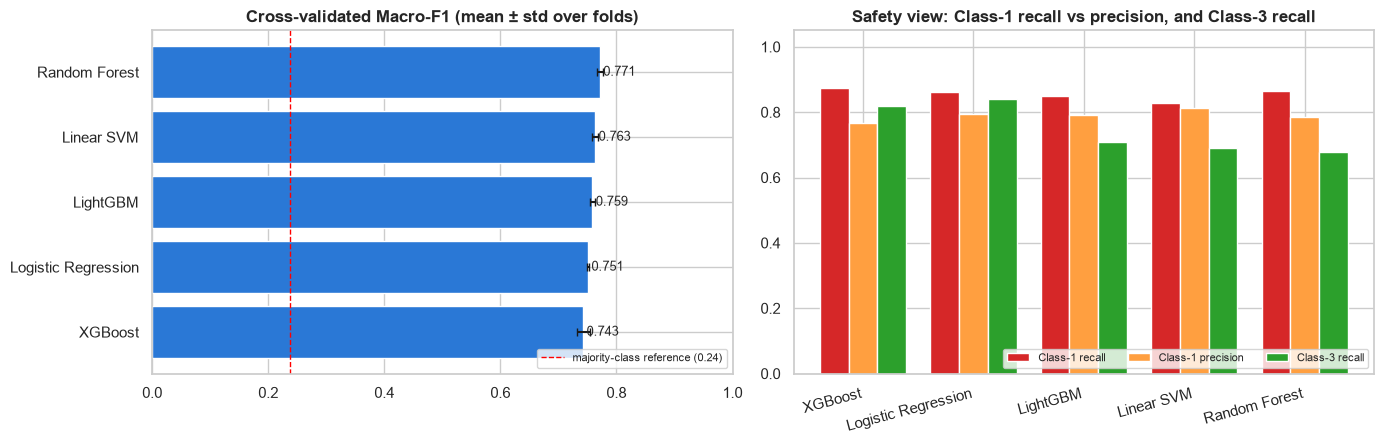

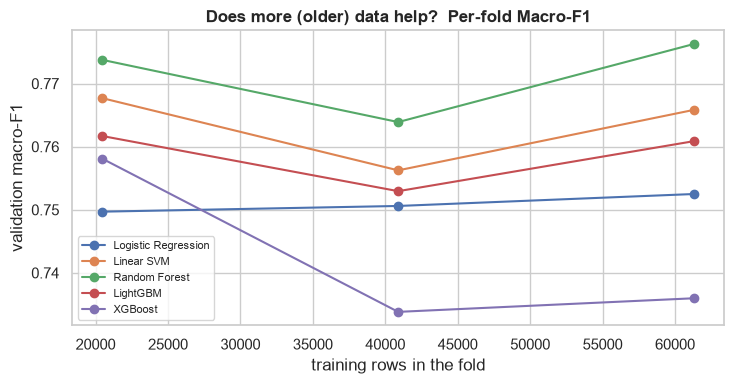

In [23]:
order = sorted(MODEL_NAMES, key=lambda n: BASELINE_RESULTS[n]["summary"]["macro_f1_mean"])
fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))
mf = [BASELINE_RESULTS[n]["summary"]["macro_f1_mean"] for n in order]; sd = [BASELINE_RESULTS[n]["summary"]["macro_f1_std"] for n in order]
ax[0].barh(order, mf, xerr=sd, capsize=3, color="#2a78d6")
for y_, v in enumerate(mf):
    ax[0].text(v + 0.006, y_, f"{v:.3f}", va="center", fontsize=9)
ax[0].axvline(DUMMY["macro_f1"][0], color="red", ls="--", lw=1, label=f"majority-class reference ({DUMMY['macro_f1'][0]:.2f})")
ax[0].set_xlim(0, 1); ax[0].set_title("Cross-validated Macro-F1 (mean ± std over folds)"); ax[0].legend(loc="lower right", fontsize=8)

x = np.arange(len(order)); w = 0.26
for j, (m, col) in enumerate([("c1_recall", "#d62728"), ("c1_precision", "#ff9f40"), ("c3_recall", "#2ca02c")]):
    vals = [BASELINE_RESULTS[n]["summary"][m + "_mean"] for n in order]
    ax[1].bar(x + (j - 1) * w, vals, w, label=METRIC_LABELS[m], color=col)
ax[1].set_xticks(x); ax[1].set_xticklabels(order, rotation=15, ha="right"); ax[1].set_ylim(0, 1.05)
ax[1].set_title("Safety view: Class-1 recall vs precision, and Class-3 recall"); ax[1].legend(ncol=3, fontsize=8, loc="lower right")
plt.tight_layout(); plt.savefig(FIG / "06_fig2_cv_comparison.png", dpi=150, bbox_inches="tight"); plt.show()

# mini learning curve: the folds have 1x, 2x, 3x training data
fig, ax = plt.subplots(figsize=(7.5, 4))
sizes = [len(f["tr_idx"]) for f in FOLDS]
for n in MODEL_NAMES:
    ax.plot(sizes, [r["macro_f1"] for r in BASELINE_RESULTS[n]["per_fold"]], marker="o", label=n)
ax.set_xlabel("training rows in the fold"); ax.set_ylabel("validation macro-F1"); ax.set_title("Does more (older) data help?  Per-fold Macro-F1")
ax.legend(fontsize=8); plt.tight_layout(); plt.savefig(FIG / "06_fig3_learning_curve.png", dpi=150, bbox_inches="tight"); plt.show()

## 6b. Hold-out test set — reported once, **not used to choose anything**
Each baseline is now fitted on the **full training period** (the stored matrices from Notebook 02) and scored once on the locked, newest test period.
This shows how the cross-validation estimate carries over to genuinely new data (the test period is the newest, so some concept drift is expected).
Decisions in Notebook 07 are taken from cross-validation only.

In [24]:
TEST_RESULTS, TEST_PRED, FITTED = {}, {}, {}
KEEP_FITTED = ("Logistic Regression", "LightGBM")      # kept for the feature-insight section (§7)

def run_test_eval(name, overrides=None):
    """Fit one baseline on the FULL training period (stored matrices from Notebook 02) and score it ONCE on the locked test set."""
    Xtr, Xte = STORED[VIEW[name]]
    model, fkw = build_model(name, overrides, y_train)
    t0 = time.time(); model.fit(Xtr, y_train, **fkw); fit_s = time.time() - t0
    t0 = time.time(); S = score_model(name, model, Xte); pred_s = time.time() - t0
    pred = S.argmax(1)
    TEST_PRED[name] = pred
    TEST_RESULTS[name] = dict(**evaluate(y_test, pred, S), fit_seconds=fit_s, predict_ms_per_1000=pred_s / len(y_test) * 1e6)
    if name in KEEP_FITTED:
        FITTED[name] = model
    else:
        del model
    gc.collect()
    print(f"{name:20s} test macro-F1 {TEST_RESULTS[name]['macro_f1']:.4f} | Class-1 recall {TEST_RESULTS[name]['c1_recall']:.3f} | fit {fit_s:.0f}s")
    return TEST_RESULTS[name]

### 6b.1 Logistic Regression — hold-out test

In [25]:
run_test_eval("Logistic Regression", {"max_iter": 500})   # more iterations for the final full-data fit

Logistic Regression  test macro-F1 0.7496 | Class-1 recall 0.880 | fit 14s


{'macro_f1': 0.7496068075568969,
 'accuracy': 0.8093801693101099,
 'balanced_accuracy': 0.8166789326389822,
 'c1_recall': 0.8798344175044353,
 'c1_precision': 0.7754612738455123,
 'c1_f1': 0.8243572695035462,
 'c2_f1': 0.8177113283496262,
 'c3_recall': 0.813953488372093,
 'c3_precision': 0.48363636363636364,
 'c3_f1': 0.6067518248175182,
 'c1_as_c3': 0.008397397989355411,
 'macro_auc_ovr': 0.939967397052312,
 'fit_seconds': 14.21228313446045,
 'predict_ms_per_1000': 0.31541685330980285}

### 6b.2 Linear SVM — hold-out test

In [26]:
run_test_eval("Linear SVM")

Linear SVM           test macro-F1 0.7634 | Class-1 recall 0.847 | fit 28s


{'macro_f1': 0.7633833247822533,
 'accuracy': 0.8201809866692614,
 'balanced_accuracy': 0.7803462847846019,
 'c1_recall': 0.8465996451803667,
 'c1_precision': 0.7955101133585241,
 'c1_f1': 0.8202601271987624,
 'c2_f1': 0.8350232940531652,
 'c3_recall': 0.6842105263157895,
 'c3_precision': 0.5921610169491526,
 'c3_f1': 0.6348665530948325,
 'c1_as_c3': 0.004612655233589592,
 'macro_auc_ovr': 0.9332290241518025,
 'fit_seconds': 28.45308232307434,
 'predict_ms_per_1000': 0.3456686609529319}

### 6b.3 Random Forest — hold-out test

In [27]:
run_test_eval("Random Forest")

Random Forest        test macro-F1 0.7734 | Class-1 recall 0.881 | fit 50s


{'macro_f1': 0.7733563126941453,
 'accuracy': 0.8193052447212221,
 'balanced_accuracy': 0.7819421758308462,
 'c1_recall': 0.8811354228267297,
 'c1_precision': 0.7689132005366911,
 'c1_f1': 0.8212081128747796,
 'c2_f1': 0.8293896713615023,
 'c3_recall': 0.6817625458996328,
 'c3_precision': 0.6576151121605667,
 'c3_f1': 0.6694711538461539,
 'c1_as_c3': 0.0014192785334121822,
 'macro_auc_ovr': 0.9387124741111729,
 'fit_seconds': 49.64909386634827,
 'predict_ms_per_1000': 12.817962329489973}

### 6b.4 LightGBM — hold-out test

In [28]:
run_test_eval("LightGBM")

LightGBM             test macro-F1 0.7545 | Class-1 recall 0.878 | fit 39s


{'macro_f1': 0.7545431619992389,
 'accuracy': 0.8106451299017223,
 'balanced_accuracy': 0.8047902902392329,
 'c1_recall': 0.8778237729154347,
 'c1_precision': 0.7719188767550702,
 'c1_f1': 0.8214720531267294,
 'c2_f1': 0.8194973343488196,
 'c3_recall': 0.773561811505508,
 'c3_precision': 0.5210222588623248,
 'c3_f1': 0.6226600985221675,
 'c1_as_c3': 0.006268480189237138,
 'macro_auc_ovr': 0.942006573463539,
 'fit_seconds': 39.41691708564758,
 'predict_ms_per_1000': 14.947374077915995}

### 6b.5 XGBoost — hold-out test

In [29]:
run_test_eval("XGBoost")

XGBoost              test macro-F1 0.7288 | Class-1 recall 0.880 | fit 117s


{'macro_f1': 0.7287997947146062,
 'accuracy': 0.7899678894619052,
 'balanced_accuracy': 0.8135946190755896,
 'c1_recall': 0.8798344175044353,
 'c1_precision': 0.7497480346704294,
 'c1_f1': 0.8095989552157589,
 'c2_f1': 0.7966992484896115,
 'c3_recall': 0.8421052631578947,
 'c3_precision': 0.442443729903537,
 'c3_f1': 0.5801011804384486,
 'c1_as_c3': 0.013837965700768775,
 'macro_auc_ovr': 0.9337037124950694,
 'fit_seconds': 117.49576330184937,
 'predict_ms_per_1000': 6.897609336164845}

### 6b.6 All models on the locked test set

In [30]:
test_table = pd.DataFrame(TEST_RESULTS).T[["macro_f1", "accuracy", "c1_recall", "c1_precision", "c3_recall", "c3_f1",
                                           "c1_as_c3", "macro_auc_ovr", "fit_seconds", "predict_ms_per_1000"]]
test_table.columns = [METRIC_LABELS.get(c, c) for c in test_table.columns[:-2]] + ["Fit time (s)", "Predict ms / 1000 rows"]
display(test_table.sort_values("Macro-F1", ascending=False).round(4))

,Macro-F1,Accuracy,Class-1 recall,Class-1 precision,Class-3 recall,Class-3 F1,Class-1 -> Class-3 rate,Macro AUC (OvR),Fit time (s),Predict ms / 1000 rows
Random Forest,0.7734,0.8193,0.8811,0.7689,0.6818,0.6695,0.0014,0.9387,49.6491,12.8180
Linear SVM,0.7634,0.8202,0.8466,0.7955,0.6842,0.6349,0.0046,0.9332,28.4531,0.3457
LightGBM,0.7545,0.8106,0.8778,0.7719,0.7736,0.6227,0.0063,0.9420,39.4169,14.9474
Logistic Regression,0.7496,0.8094,0.8798,0.7755,0.8140,0.6068,0.0084,0.9400,14.2123,0.3154
XGBoost,0.7288,0.7900,0.8798,0.7497,0.8421,0.5801,0.0138,0.9337,117.4958,6.8976


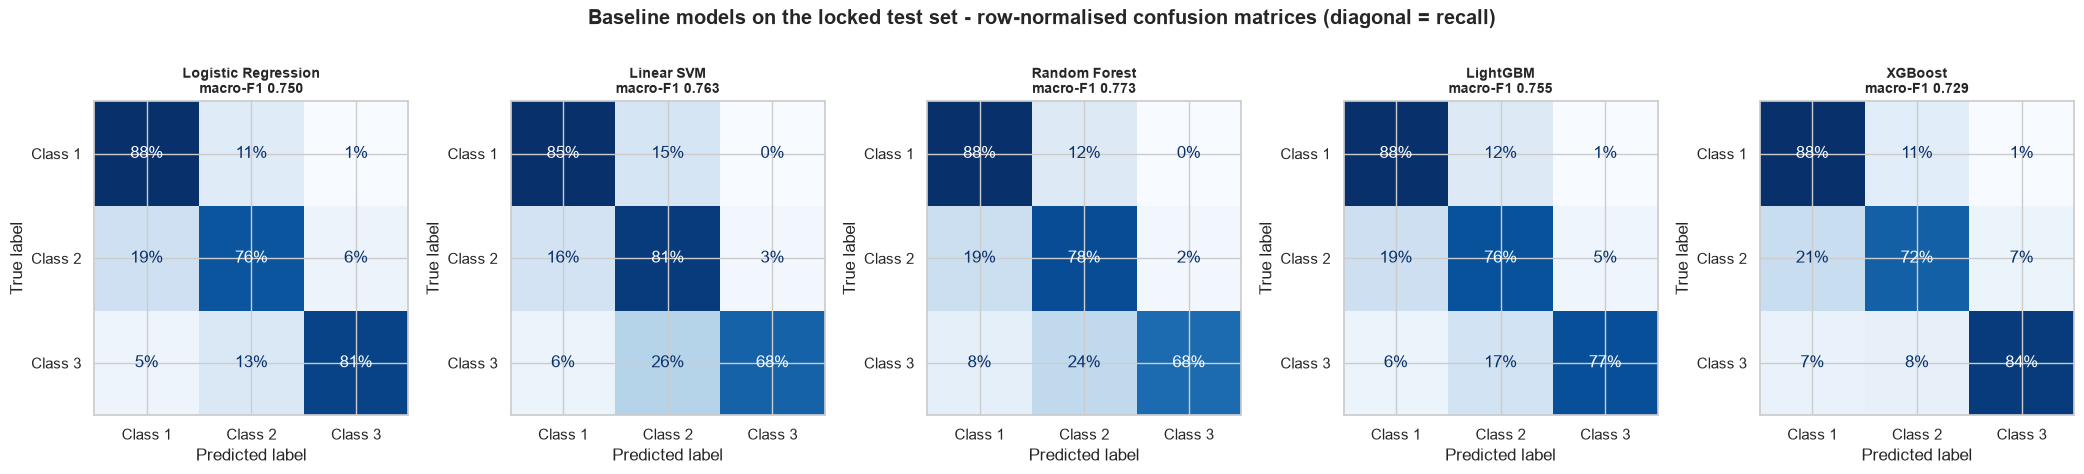

In [31]:
fig, axes = plt.subplots(1, 5, figsize=(21, 4.4))
for ax, name in zip(axes, MODEL_NAMES):
    ConfusionMatrixDisplay.from_predictions(y_test, TEST_PRED[name], labels=[0, 1, 2], display_labels=SHORT, normalize="true",
                                            cmap="Blues", ax=ax, colorbar=False, values_format=".0%")
    ax.set_title(f"{name}\nmacro-F1 {TEST_RESULTS[name]['macro_f1']:.3f}", fontsize=10)
plt.suptitle("Baseline models on the locked test set - row-normalised confusion matrices (diagonal = recall)", y=1.04, fontweight="bold")
plt.tight_layout(); plt.savefig(FIG / "06_fig4_confusion_matrices.png", dpi=150, bbox_inches="tight"); plt.show()

## 7. Why do some models do better or worse?
The observations below are **generated from the results above** (so they stay correct if you re-run), followed by feature-level evidence.

In [32]:
cvm = pd.DataFrame({n: {m: r["summary"][m + "_mean"] for m in ["macro_f1", "accuracy", "c1_recall", "c1_precision", "c3_recall", "c1_f1", "c2_f1", "c3_f1"]}
                    for n, r in BASELINE_RESULTS.items()}).T.sort_values("macro_f1", ascending=False)
lin = [n for n in cvm.index if VIEW[n] == "linear"]; tre = [n for n in cvm.index if VIEW[n] == "tree"]
bl, bt = cvm.loc[lin, "macro_f1"].idxmax(), cvm.loc[tre, "macro_f1"].idxmax()
gap = cvm.loc[bt, "macro_f1"] - cvm.loc[bl, "macro_f1"]
obs = []
obs.append(f"1. Ranking by CV macro-F1: " + " > ".join(f"{n} ({v:.3f})" for n, v in cvm["macro_f1"].items()) + f".  All beat the majority-class reference ({DUMMY['macro_f1'][0]:.2f}).")
verdict = ("trees capture interactions the linear models cannot" if gap > 0.01 else
           "text is close to linearly separable - extra model flexibility buys little" if abs(gap) <= 0.01 else "the linear models are better on this data")
obs.append(f"2. Best linear = {bl} ({cvm.loc[bl, 'macro_f1']:.3f}); best tree-based = {bt} ({cvm.loc[bt, 'macro_f1']:.3f}); difference {gap:+.3f} -> {verdict}.")
typ_std = np.mean([BASELINE_RESULTS[n]["summary"]["macro_f1_std"] for n in MODEL_NAMES])
obs.append(f"3. Typical fold-to-fold std of macro-F1 is {typ_std:.3f}; differences between models smaller than that are NOT reliable evidence.")
cls_f1 = cvm[["c1_f1", "c2_f1", "c3_f1"]].mean()
obs.append(f"4. Hardest class on average: {cls_f1.idxmin().replace('_f1', '').replace('c', 'Class ')} (mean F1 {cls_f1.min():.3f}) vs easiest {cls_f1.idxmax().replace('_f1', '').replace('c', 'Class ')} ({cls_f1.max():.3f}).")
gain = {n: BASELINE_RESULTS[n]["per_fold"][-1]["macro_f1"] - BASELINE_RESULTS[n]["per_fold"][0]["macro_f1"] for n in MODEL_NAMES}
hungry = max(gain, key=gain.get)
obs.append(f"5. Data hunger: macro-F1 gain from fold 1 (smallest training window) to fold 3 is largest for {hungry} ({gain[hungry]:+.3f}); "
           f"smallest for {min(gain, key=gain.get)} ({min(gain.values()):+.3f}).")
pred_share = {n: np.bincount(TEST_PRED[n], minlength=3) / len(y_test) * 100 for n in MODEL_NAMES}
true_share = np.bincount(y_test, minlength=3) / len(y_test) * 100
bias_model = max(MODEL_NAMES, key=lambda n: abs(pred_share[n][0] - true_share[0]))
obs.append(f"6. Class-1 over/under-calling on test (true share {true_share[0]:.1f}%): most biased = {bias_model} predicts Class 1 for "
           f"{pred_share[bias_model][0]:.1f}% of rows (precision {TEST_RESULTS[bias_model]['c1_precision']:.2f}); a high recall bought with low precision is not a real win.")
drift = {n: TEST_RESULTS[n]["macro_f1"] - BASELINE_RESULTS[n]["summary"]["macro_f1_mean"] for n in MODEL_NAMES}
obs.append("7. CV -> test change in macro-F1 (negative = newer data is harder / drift): " + ", ".join(f"{n} {v:+.3f}" for n, v in drift.items()) + ".")
slow = max(MODEL_NAMES, key=lambda n: BASELINE_RESULTS[n]["fit_s"]); fast = min(MODEL_NAMES, key=lambda n: BASELINE_RESULTS[n]["fit_s"])
obs.append(f"8. Cost: slowest to train = {slow} ({BASELINE_RESULTS[slow]['fit_s']:.0f}s/fold), fastest = {fast} ({BASELINE_RESULTS[fast]['fit_s']:.0f}s/fold). Speed matters when retraining regularly.")
print("\n".join(obs))

1. Ranking by CV macro-F1: Random Forest (0.771) > Linear SVM (0.763) > LightGBM (0.759) > Logistic Regression (0.751) > XGBoost (0.743).  All beat the majority-class reference (0.24).
2. Best linear = Linear SVM (0.763); best tree-based = Random Forest (0.771); difference +0.008 -> text is close to linearly separable - extra model flexibility buys little.
3. Typical fold-to-fold std of macro-F1 is 0.005; differences between models smaller than that are NOT reliable evidence.
4. Hardest class on average: Class 3 (mean F1 0.618) vs easiest Class 2 (0.832).
5. Data hunger: macro-F1 gain from fold 1 (smallest training window) to fold 3 is largest for Logistic Regression (+0.003); smallest for XGBoost (-0.022).
6. Class-1 over/under-calling on test (true share 41.1%): most biased = XGBoost predicts Class 1 for 48.3% of rows (precision 0.75); a high recall bought with low precision is not a real win.
7. CV -> test change in macro-F1 (negative = newer data is harder / drift): Logistic Regres

### Feature-level evidence — what does the text signal look like?

#### Logistic Regression — words / features that push towards each class

In [33]:
# --- Logistic Regression: words/features that push towards each class (positive coefficients)
lr = FITTED["Logistic Regression"]
tops = {}
for i, c in enumerate(CLASS_NAMES):
    idx = np.argsort(lr.coef_[i])[::-1][:10]
    tops[c] = [f"{names_linear[j]}  ({lr.coef_[i][j]:+.1f})" for j in idx]
display(pd.DataFrame(tops).rename(columns={c: f"{c} ({CLASS_MEANING[c]})" for c in CLASS_NAMES}))

,CLASS - 1 (Immediately hazardous),CLASS - 2 (Major),CLASS - 3 (Lesser)
0,text__AND REPLACE (+9.0),text__OBTAIN ALL (+7.6),text__PERMIT OR (+4.5)
1,text__OBTAIN PERMIT (+5.0),text__ALL PERMITS (+6.1),text__HEIGHT (+4.3)
2,text__CEASE (+4.3),text__OR REPLACE (+4.1),text__OR RESTORE (+4.1)
3,text__PERMIT VIOLATION (+3.7),text__FILE CERTIFICATE (+3.8),text__FENCE (+4.1)
4,text__CEASE USE (+3.6),text__ALL (+2.9),text__OR REPLACE (+3.8)
5,text__ORDER (+3.3),text__CORRECTION (+2.8),text__PARKING (+3.7)
6,cat__VIOLATION_TYPE_Site Safety (+3.2),text__AND OR (+2.7),text__SIGN (+3.6)
7,text__WITH COMMISSIONER (+3.1),text__CONSTRUCTION FENCE (+2.7),text__CURB (+3.5)
8,text__ATOI (+2.9),cat__VIOLATION_TYPE_Local Law (+2.7),text__OR (+3.3)
9,text__RESTRICTOR (+2.7),text__FILE (+2.4),text__AND OR (+3.3)


#### LightGBM — which features carry the splits

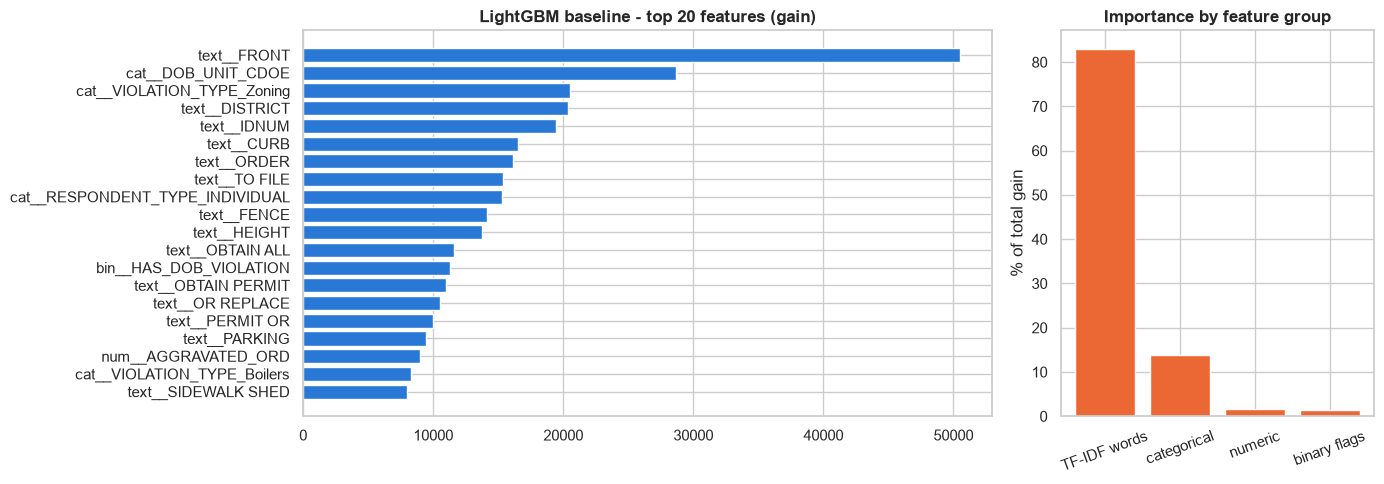

Share of total gain by group (%): {'TF-IDF words': 83.0, 'categorical': 13.9, 'numeric': 1.6, 'binary flags': 1.5}


In [34]:
# --- LightGBM: which features carry the splits (gain), and which feature GROUP dominates
gain_imp = pd.Series(FITTED["LightGBM"].booster_.feature_importance(importance_type="gain"), index=names_tree).sort_values(ascending=False)
grp_map = {"text": "TF-IDF words", "cat": "categorical", "num": "numeric", "bin": "binary flags"}
grp_share = gain_imp.groupby(lambda n: grp_map.get(n.split("__")[0], "other")).sum()
grp_share = (grp_share / grp_share.sum() * 100).round(1).sort_values(ascending=False)
fig, ax = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2.2, 1]})
top = gain_imp.head(20)[::-1]
ax[0].barh(top.index, top.values, color="#2a78d6"); ax[0].set_title("LightGBM baseline - top 20 features (gain)")
ax[1].bar(grp_share.index, grp_share.values, color="#eb6834"); ax[1].set_ylabel("% of total gain"); ax[1].set_title("Importance by feature group")
ax[1].tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(FIG / "06_fig5_feature_insight.png", dpi=150, bbox_inches="tight"); plt.show()
print("Share of total gain by group (%):", grp_share.to_dict())

### Typical reasons behind the pattern (check each against your own tables above)

* **Linear models on sparse text.** With 40 000 word/bigram columns and ~80 k rows, a *linear* boundary is often almost enough — each key phrase ("FILE CERTIFICATE", "PERMITTED HEIGHT", "SCAFFOLD") votes for a class. Regularisation (`C`) is the main control. The SVM optimises margin, Logistic Regression optimises likelihood; with class weights, Logistic Regression tends to **over-call the minority/safety class** (high recall, low precision), which shows in the confusion matrix.
* **Random Forest on sparse text.** Each split only inspects ~√5 000 ≈ 70 random columns, most of which are zero for a given row, so many splits are weak; it needs many deep trees. It does combine text with context (violation type, building history) and is robust, but its vote fractions are poorly calibrated.
* **Gradient boosting.** Trees are built one after another, each fixing the previous errors; this models **interactions** (e.g. a phrase means something different for a given violation type or for a repeat-offender building) and benefits from more data (see the learning-curve figure). The cost is more hyper-parameters and a risk of over-fitting the rare class — that is what Notebook 07 tunes.
* **LightGBM vs XGBoost.** Same idea, different tree-growing strategy (leaf-wise vs level-wise). Any gap here is mostly settings/speed, not a fundamental difference.
* **Class weights.** Weighting Class 3 about 14× heavier than Class 2 raises its recall but lowers its precision (some Class 2 get flagged as Class 3). Whether that trade is worth it is a stakeholder decision — Notebook 07 tests the weight strength.
* **Why scores drop on the test period.** The test violations are the *newest*; inspector wording, enforcement campaigns and the class mix drift over time. This is why the validation is time-ordered and why periodic retraining is recommended.

## 8. Record experiments and results
Every run is appended to `results/experiment_log.csv` (model, parameters, CV metrics, fit time, timestamp). Summary tables are saved as CSV/JSON so Notebook 07 and the technical report can use them without re-running anything.

In [35]:
cv_numeric = pd.DataFrame({n: {k: v for k, v in r["summary"].items()} for n, r in BASELINE_RESULTS.items()}).T
cv_numeric["fit_seconds_per_fold"] = [BASELINE_RESULTS[n]["fit_s"] for n in cv_numeric.index]
cv_numeric.round(5).to_csv(RESULTS / "stage6_baseline_cv.csv")
test_table.round(5).to_csv(RESULTS / "stage6_baseline_test.csv")

summary = {
    "notebook": NB, "quick_run": QUICK_RUN, "created": datetime.now().isoformat(timespec="seconds"),
    "validation": f"TimeSeriesSplit(n_splits={N_SPLITS}) expanding window, preprocessing re-fitted inside each fold",
    "primary_metric": "macro_f1", "safety_metric": "class-1 recall (with class-1 precision)",
    "baseline_configs": {n: BASELINE[n] for n in MODEL_NAMES},
    "cv_macro_f1": {n: round(BASELINE_RESULTS[n]["summary"]["macro_f1_mean"], 4) for n in MODEL_NAMES},
    "test_macro_f1": {n: round(TEST_RESULTS[n]["macro_f1"], 4) for n in MODEL_NAMES},
    "majority_class_cv_macro_f1": round(DUMMY["macro_f1"][0], 4),
    "observations": obs,
}
json.dump(summary, open(RESULTS / "stage6_summary.json", "w"), indent=2, default=str)
# per-fold baseline results: Notebook 07 re-uses these (same folds) instead of re-running the baselines
json.dump({n: dict(params=r["params"], best_iter=r["best_iter"], per_fold=r["per_fold"], fit_s=r["fit_s"], n_features=r["n_features"])
           for n, r in BASELINE_RESULTS.items()}, open(RESULTS / "stage6_baseline_folds.json", "w"), indent=2, default=str)
path, n_rows = save_experiment_log(NB)
print("Saved:", *(p.name for p in sorted(RESULTS.glob("stage6_*"))), "|", path.name, f"({n_rows} rows)")
print("Figures:", *(p.name for p in sorted(FIG.glob("06_*"))))

Saved: stage6_baseline_cv.csv stage6_baseline_folds.json stage6_baseline_test.csv stage6_summary.json | experiment_log.csv (5 rows)
Figures: 06_fig1_validation_timeline.png 06_fig2_cv_comparison.png 06_fig3_learning_curve.png 06_fig4_confusion_matrices.png 06_fig5_feature_insight.png


## 9. Summary and hand-over to Notebook 07
* Five algorithms were compared on **identical, leakage-safe, time-ordered folds** with identical metrics; the locked test set was used once for reporting.
* The results table (§6) and the observations (§7) show which families work best on this data, the price paid in false alarms, and where the rare Class 3 and the safety-critical Class 1 stand.
* **Next (Notebook 07):** tune every family with a random search on the same folds, test whether feature selection / class-weight strength help, apply a **pre-declared selection rule**, then train, evaluate and export the final model for the backend.

---
## Viva preparation — likely questions on this stage

**Q: Why Macro-F1 and not accuracy?**
A: Class 3 is ≈ 4 % of rows. A model that never predicts it still scores ~85 % accuracy. Macro-F1 averages the per-class F1 so every class counts equally. Class-1 recall is added because missing a hazardous violation is the costly error.

**Q: Why time-series CV instead of normal K-fold?**
A: The system predicts future violations and the history features look backwards. Random folds would train on later rows and test on earlier ones, inflating scores. Expanding windows copy real use: train on the past, test on what comes next.

**Q: Why did you re-fit TF-IDF and chi² inside every fold?**
A: Chi² uses the labels. If it was fitted on all training rows, the validation rows' labels would already have influenced which features are kept — a subtle leak. Fitting inside each fold removes it.

**Q: Why do Logistic Regression and the SVM get all features but trees only 5 000?**
A: Notebook 02's validation curve showed selection does not help linear models, whereas tree ensembles are slow on 40 k sparse columns and lose little with the top 5 000.

**Q: A model has the highest Class-1 recall. Is it the best?**
A: Not necessarily. Check Class-1 precision and the confusion matrix: a model that labels most violations "Class 1" has high recall and many false alarms. The comparison therefore looks at macro-F1, recall *and* precision together.

**Q: Why class weights and not SMOTE?**
A: There are thousands of real Class 3 rows. Weights change the loss without inventing synthetic text vectors, and they cannot leak across folds.

**Q: Why is the test score lower than the CV score?**
A: The test period is the newest data; wording and class mix drift over time. A lower test score is the honest estimate of deployment performance, which is why the test set is only used for reporting.

**Q: How do you know a difference between two models is real?**
A: Compare it with the fold-to-fold standard deviation (§7, point 3). Differences within one standard deviation are treated as ties.